In [107]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("../../src")
from structure import fcc_positions
from utils import write_extxyz
from lennard_jones import lj_potential, compute_lj_force

In [108]:
sigma = 10.0
epsilon = 1.0

a = 2 ** (1 / 6) * sigma  # 平衡距離
n_cells = 2
pos = fcc_positions(np.sqrt(2) * a, n_cells)

num_particles = pos.shape[0]
# pos[0] += np.array([0.1, 0.1, 0.1])  # 原子0を少しずらす

initial_positions = pos

In [109]:
# initial_velocities = np.zeros_like(initial_positions)
masses = np.ones(num_particles)

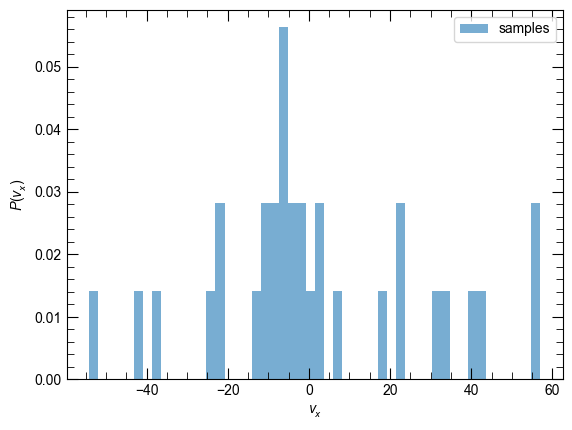

In [110]:
beta = 1e-3
m = masses[0]
vx_samples = np.random.normal(0, np.sqrt(m / beta), num_particles)
vy_samples = np.random.normal(0, np.sqrt(m / beta), num_particles)
vz_samples = np.random.normal(0, np.sqrt(m / beta), num_particles)

plt.hist(vx_samples, bins=50, density=True, alpha=0.6, label="samples")
# plt.plot(vx, P(vx, m, kB, T), 'r-', lw=2, label="theory")
plt.xlabel(r"$v_x$")
plt.ylabel(r"$P(v_x)$")
plt.legend()
plt.show()

In [111]:
# 初期速度の設定 by vx, vy, vz samples
initial_velocities = np.vstack((vx_samples, vy_samples, vz_samples)).T

In [112]:
total_time = 100.0
num_steps = 1000
dt = total_time / num_steps
pos_T = np.zeros((num_steps, initial_positions.shape[0], initial_positions.shape[1]))
pos_T[0] = initial_positions
pos_T[1] = initial_positions + initial_velocities * dt
box = [
    [0, np.sqrt(2) * a * n_cells],
    [0, np.sqrt(2) * a * n_cells],
    [0, np.sqrt(2) * a * n_cells],
]  # シミュレーションボックスの範囲
r_cutoff = 2.5 * sigma  # カットオフ距離

In [113]:
t = 1
r_vec = pos_T[t, 1] - pos_T[t, 0]
force_on_0 = compute_lj_force(r_vec, sigma, epsilon)
force_on_1 = -force_on_0
print("Force on particle 0 at step", t, ":", force_on_0)
print("Force on particle 1 at step", t, ":", force_on_1)

Force on particle 0 at step 1 : [-0.01384875 -0.01881165 -0.01446917]
Force on particle 1 at step 1 : [0.01384875 0.01881165 0.01446917]


In [114]:
def apply_periodic_boundary(r_vec, box):
    L = (
        box[0][1] - box[0][0],
        box[1][1] - box[1][0],
        box[2][1] - box[2][0],
    )  # シミュレーションボックスのサイズ
    for dim in range(len(r_vec)):
        if r_vec[dim] > L[dim] / 2:
            r_vec[dim] -= L[dim]
        elif r_vec[dim] < -L[dim] / 2:
            r_vec[dim] += L[dim]
    return r_vec

In [115]:
num_particles = pos_T.shape[1]
forces_traj = np.zeros(
    (num_steps, initial_positions.shape[0], initial_positions.shape[1])
)
L = (
    box[0][1] - box[0][0],
    box[1][1] - box[1][0],
    box[2][1] - box[2][0],
)  # シミュレーションボックスのサイズ
for t in range(1, num_steps - 1):
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            r_vec = pos_T[t, i] - pos_T[t, j]
            r_vec = apply_periodic_boundary(r_vec, box)

            force_ij = compute_lj_force(r_vec, sigma, epsilon)

            forces_traj[t, i] += force_ij
            forces_traj[t, j] -= force_ij

    for i in range(num_particles):
        acceleration = forces_traj[t, i] / masses[i]
        pos_T[t + 1, i] = 2 * pos_T[t, i] - pos_T[t - 1, i] + acceleration * dt**2
        pos_T[t + 1, i] = pos_T[t + 1, i] % L  # PBC適用

In [116]:
write_extxyz("trhee_d_lj.xyz", pos_T, box=box)

Wrote Extended XYZ: trhee_d_lj.xyz


In [117]:
# pair distribution calculation with PBC

r_hist = np.zeros(100)
dr = np.sqrt(3) * L[0] / (2 * len(r_hist))
max_r = dr * len(r_hist)

for t in range(1, num_steps - 1):
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            r_vec = pos_T[t, i] - pos_T[t, j]
            r_vec = apply_periodic_boundary(r_vec, box)
            dist = np.linalg.norm(r_vec)
            if dist < max_r:
                bin_index = int(dist / dr)
                r_hist[bin_index] += 2  # i-jとj-iの両方をカウント
# 正規化
r_hist /= num_steps

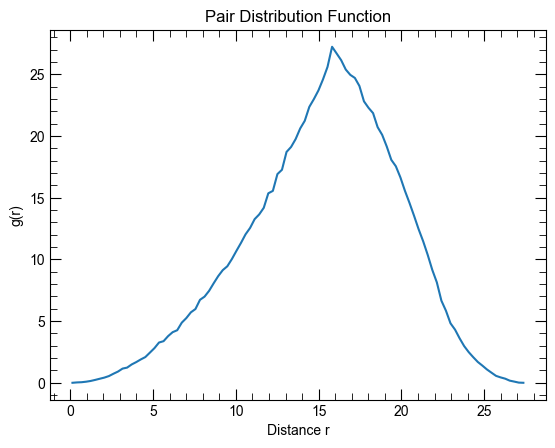

In [118]:
fig, ax = plt.subplots()
r_values = (np.arange(len(r_hist)) + 0.5) * dr
ax.plot(r_values, r_hist)
ax.set_xlabel("Distance r")
ax.set_ylabel("g(r)")
ax.set_title("Pair Distribution Function")
plt.show()